# Multivariate EDA: AUS University Enrollments & Total Funding

This notebook analyzes the relationship between Australian university enrollments and funding by category and year, using the exact column names and categories from the clean data files.

**Data sources:**
- Enrollments: `data/clean/EnrollmentsAUS_category_with_numeric_key.csv`
- Funding: `data/clean/AnnualFundingAUS2019-2026_with_category_key.csv`

**Key columns:**
- Category, CategoryKey, Year, Enrollments
- MaximumStudentContribution, CommonwealthContribution, TotalFunding

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

In [2]:
# Load data with correct columns and robust path handling
import os
from pathlib import Path

# Resolve the correct path after moving the notebook into a deeper subfolder
candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
clean_dir = None

for root in candidate_roots:
    candidate = root / 'data' / 'clean'
    if candidate.exists():
        clean_dir = candidate
        break

if clean_dir is None:
    raise FileNotFoundError(f"Could not locate data/clean from working directory: {Path.cwd()}")

print('Current working directory:', os.getcwd())
print('Resolved data/clean path:', clean_dir)
print('Files in data/clean:', list(clean_dir.iterdir())[:10])

# Load data
enrollments = pd.read_csv(clean_dir / 'EnrollmentsAUS_category_with_numeric_key.csv')
funding = pd.read_csv(clean_dir / 'AnnualFundingAUS2019-2026_with_category_key.csv')

# Ensure correct dtypes
funding['Year'] = funding['Year'].astype(int)
if 'TotalFunding' not in funding.columns:
    funding['TotalFunding'] = funding['MaximumStudentContribution'] + funding['CommonwealthContribution']

Current working directory: C:\Users\neddp\ECC3479-Project-JRGS\docs\EDA analysis
Resolved data/clean path: C:\Users\neddp\ECC3479-Project-JRGS\data\clean
Files in data/clean: [WindowsPath('C:/Users/neddp/ECC3479-Project-JRGS/data/clean/AnnualFundingAUS2019-2026.csv'), WindowsPath('C:/Users/neddp/ECC3479-Project-JRGS/data/clean/AnnualFundingAUS2019-2026.xlsx'), WindowsPath('C:/Users/neddp/ECC3479-Project-JRGS/data/clean/AnnualFundingAUS2019-2026_category_summary.csv'), WindowsPath('C:/Users/neddp/ECC3479-Project-JRGS/data/clean/AnnualFundingAUS2019-2026_with_category_key.csv'), WindowsPath('C:/Users/neddp/ECC3479-Project-JRGS/data/clean/employment_by_industry_20y+keys.csv'), WindowsPath('C:/Users/neddp/ECC3479-Project-JRGS/data/clean/employment_by_industry_20y+keys.xlsx'), WindowsPath('C:/Users/neddp/ECC3479-Project-JRGS/data/clean/employment_by_industry_20y.csv'), WindowsPath('C:/Users/neddp/ECC3479-Project-JRGS/data/clean/employment_by_industry_20y.xlsx'), WindowsPath('C:/Users/neddp/

## 1. Data Overview

In [3]:
# Show structure and preview
display(enrollments.head())
display(funding.head())

,Category,2016,2017,2018,2019,2020,2021,2022,2023,2024,CategoryKey
0,Natural & Physical Science,119102,124209,129609,134334,136733,139629,134424,132406,134511,1
1,Information Technology,66355,80090,99986,116623,120916,116296,119278,143253,164464,2
2,Engineering & Related Tech,111060,115231,119909,121980,118229,112931,109812,115197,122954,3
3,Architecture & Building,32074,35604,39459,42370,43478,43773,42327,42174,40942,4
4,Environment & Related,18537,18260,18055,18747,21916,20776,19476,19284,19376,5


,Year,FOE,FOE_Description,FundingCluster,MaximumStudentContribution,CommonwealthContribution,FOE_Broad,CategoryKey,Category,TotalFunding
0,2019,90701,Psychology (Not professional pathway psycholog...,Funding Cluster 3,6566,10630,9.0,9,Society & Culture,17196
1,2019,90701,Psychology (Not professional pathway psycholog...,Funding Cluster 5,6566,13073,9.0,9,Society & Culture,19639
2,2019,80100,Accounting,Funding Cluster 1,10958,2160,8.0,8,Management & Commerce,13118
3,2019,80101,Accounting,Funding Cluster 1,10958,2160,8.0,8,Management & Commerce,13118
4,2019,80300,Business and Management,Funding Cluster 1,10958,2160,8.0,8,Management & Commerce,13118


## 2. Clean and Reshape Data

In [4]:
# Reshape enrollments to long format with correct columns
# Exclude 'Total' row if present
if 'Year' not in enrollments.columns:
    enroll_long = enrollments.melt(id_vars=['Category', 'CategoryKey'], var_name='Year', value_name='Enrollments')
    enroll_long = enroll_long[enroll_long['Category'] != 'Total']
    enroll_long['Year'] = enroll_long['Year'].astype(int)
else:
    enroll_long = enrollments.copy()

In [5]:
# Add total funding column if not present
if 'TotalFunding' not in funding.columns:
    funding['TotalFunding'] = funding['MaximumStudentContribution'] + funding['CommonwealthContribution']

## 3. Merge Datasets by Category and Year

In [6]:
# Group funding by year/category using correct columns
funding_grouped = funding.groupby(['Year', 'CategoryKey', 'Category'], as_index=False)[['CommonwealthContribution', 'TotalFunding']].sum()

# Merge on Year and CategoryKey and Category
merged = pd.merge(enroll_long, funding_grouped, on=['Year', 'CategoryKey', 'Category'], how='inner')
display(merged.head())

,Category,CategoryKey,Year,Enrollments,CommonwealthContribution,TotalFunding
0,Natural & Physical Science,1,2019,134334,660862,1008744
1,Information Technology,2,2019,116623,223230,419769
2,Engineering & Related Tech,3,2019,121980,1486880,2235600
3,Architecture & Building,4,2019,42370,244490,459747
4,Environment & Related,5,2019,18747,448210,626031


## 4. Trends: Enrollments and Funding by Category

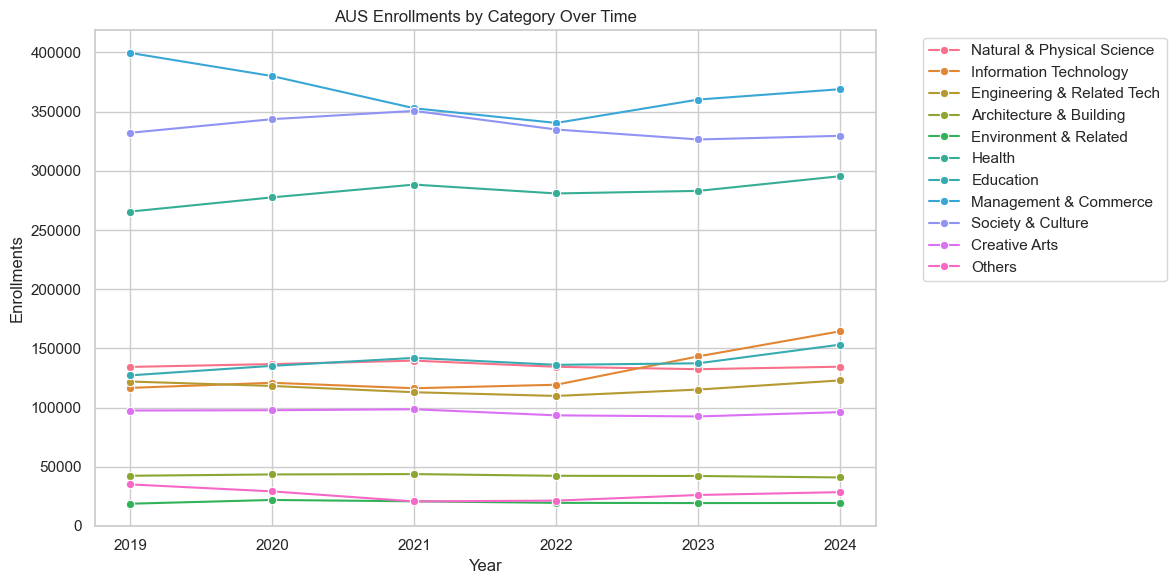

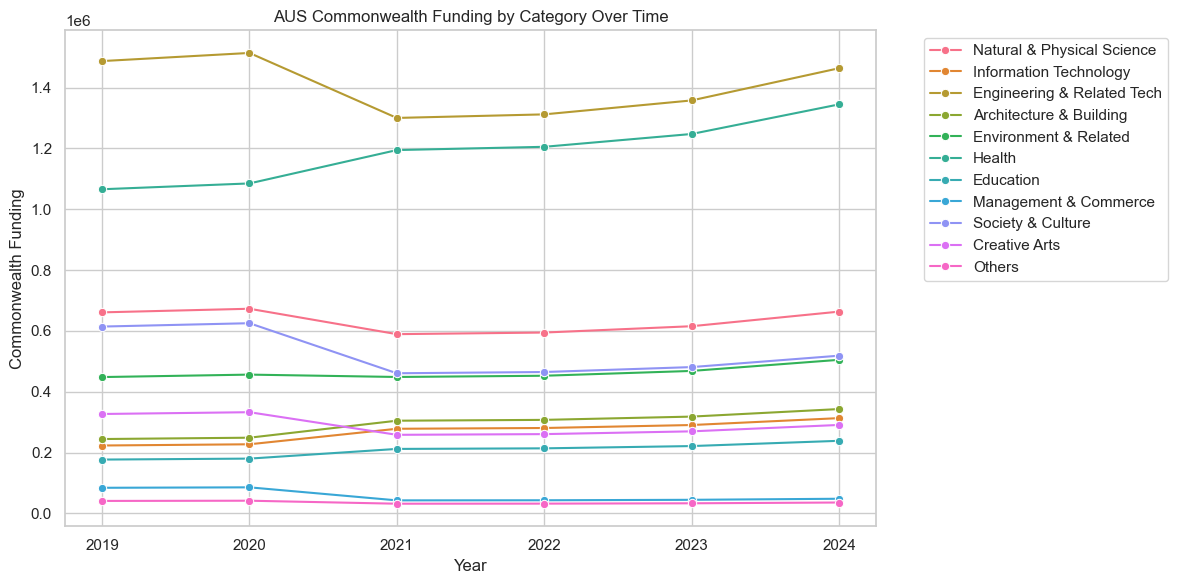

In [7]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=merged, x='Year', y='Enrollments', hue='Category', marker='o')
plt.title('AUS Enrollments by Category Over Time')
plt.ylabel('Enrollments')
plt.xlabel('Year')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.lineplot(data=merged, x='Year', y='CommonwealthContribution', hue='Category', marker='o')
plt.title('AUS Commonwealth Funding by Category Over Time')
plt.ylabel('Commonwealth Funding')
plt.xlabel('Year')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 5. Relationship: Funding vs Enrollments

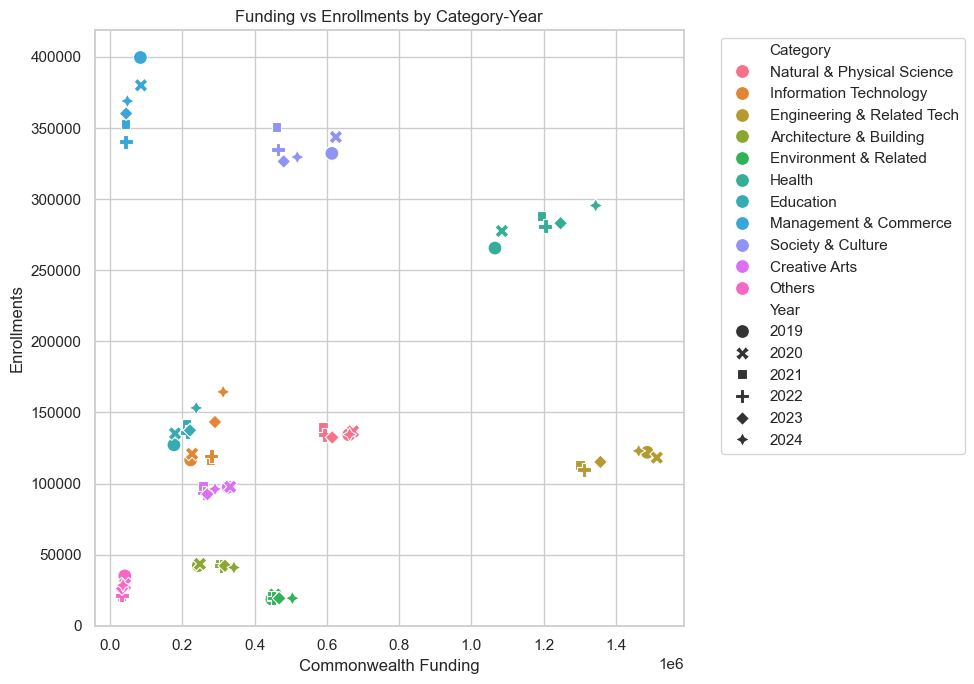

In [8]:
# Scatter plot: Funding vs Enrollments by category-year
plt.figure(figsize=(10, 7))
sns.scatterplot(data=merged, x='CommonwealthContribution', y='Enrollments', hue='Category', style='Year', s=100)
plt.title('Funding vs Enrollments by Category-Year')
plt.xlabel('Commonwealth Funding')
plt.ylabel('Enrollments')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [9]:
# Verify resolved paths (informational)
import os
from pathlib import Path
candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
clean_dir = next((r / 'data' / 'clean' for r in candidate_roots if (r / 'data' / 'clean').exists()), None)
print('Current working directory:', os.getcwd())
print('Resolved data/clean path:', clean_dir)
if clean_dir:
    print('Files in data/clean:', [f.name for f in list(clean_dir.iterdir())[:10]])

Current working directory: C:\Users\neddp\ECC3479-Project-JRGS\docs\EDA analysis
Resolved data/clean path: C:\Users\neddp\ECC3479-Project-JRGS\data\clean
Files in data/clean: ['AnnualFundingAUS2019-2026.csv', 'AnnualFundingAUS2019-2026.xlsx', 'AnnualFundingAUS2019-2026_category_summary.csv', 'AnnualFundingAUS2019-2026_with_category_key.csv', 'employment_by_industry_20y+keys.csv', 'employment_by_industry_20y+keys.xlsx', 'employment_by_industry_20y.csv', 'employment_by_industry_20y.xlsx', 'employment_by_industry_20y_transposed.csv', 'employment_by_industry_20y_transposed.xlsx']


# Multivariate EDA: AUS Enrollments & Funding

This notebook explores the relationship between university enrollments and funding in Australia, by category and over time.

**Data Sources:**
- Enrollments: `data/clean/EnrollmentsAUS_category_with_numeric_key.csv`
- Funding: `data/clean/AnnualFundingAUS2019-2026_with_category_key.csv`

**Objectives:**
- Overview and clean both datasets
- Analyze missing values
- Compare funding trends (Commonwealth contributions) and enrollments over years by category, ensuring categories are matched using keys

In [10]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Data Overview
Let's check the structure and summary of both datasets.

In [11]:
# Overview of enrollments
enroll_long.info()
display(enroll_long.head())

<class 'pandas.DataFrame'>
Index: 99 entries, 0 to 106
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Category     99 non-null     str  
 1   CategoryKey  99 non-null     int64
 2   Year         99 non-null     int64
 3   Enrollments  99 non-null     int64
dtypes: int64(3), str(1)
memory usage: 3.9 KB


,Category,CategoryKey,Year,Enrollments
0,Natural & Physical Science,1,2016,119102
1,Information Technology,2,2016,66355
2,Engineering & Related Tech,3,2016,111060
3,Architecture & Building,4,2016,32074
4,Environment & Related,5,2016,18537


In [12]:
# Overview of funding
funding.info()
display(funding.head())

<class 'pandas.DataFrame'>
RangeIndex: 3484 entries, 0 to 3483
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        3484 non-null   int64  
 1   FOE                         3484 non-null   str    
 2   FOE_Description             3484 non-null   str    
 3   FundingCluster              3484 non-null   str    
 4   MaximumStudentContribution  3484 non-null   int64  
 5   CommonwealthContribution    3484 non-null   int64  
 6   FOE_Broad                   3482 non-null   float64
 7   CategoryKey                 3484 non-null   int64  
 8   Category                    3484 non-null   str    
 9   TotalFunding                3484 non-null   int64  
dtypes: float64(1), int64(5), str(4)
memory usage: 272.3 KB


,Year,FOE,FOE_Description,FundingCluster,MaximumStudentContribution,CommonwealthContribution,FOE_Broad,CategoryKey,Category,TotalFunding
0,2019,90701,Psychology (Not professional pathway psycholog...,Funding Cluster 3,6566,10630,9.0,9,Society & Culture,17196
1,2019,90701,Psychology (Not professional pathway psycholog...,Funding Cluster 5,6566,13073,9.0,9,Society & Culture,19639
2,2019,80100,Accounting,Funding Cluster 1,10958,2160,8.0,8,Management & Commerce,13118
3,2019,80101,Accounting,Funding Cluster 1,10958,2160,8.0,8,Management & Commerce,13118
4,2019,80300,Business and Management,Funding Cluster 1,10958,2160,8.0,8,Management & Commerce,13118


## Missing Values Analysis
Check for missing values in both datasets.

In [13]:
# Missing values in enrollments
display(enroll_long.isnull().sum())

Category       0
CategoryKey    0
Year           0
Enrollments    0
dtype: int64

In [14]:
# Missing values in funding
display(funding.isnull().sum())

Year                          0
FOE                           0
FOE_Description               0
FundingCluster                0
MaximumStudentContribution    0
CommonwealthContribution      0
FOE_Broad                     2
CategoryKey                   0
Category                      0
TotalFunding                  0
dtype: int64

## Funding Trends vs Enrollments by Category
We will compare Commonwealth funding and enrollments over years for each category. Categories are matched using the numeric key.

,Year,CategoryKey,Category,Enrollments
0,2016,1,Natural & Physical Science,119102
1,2016,2,Information Technology,66355
2,2016,3,Engineering & Related Tech,111060
3,2016,4,Architecture & Building,32074
4,2016,5,Environment & Related,18537


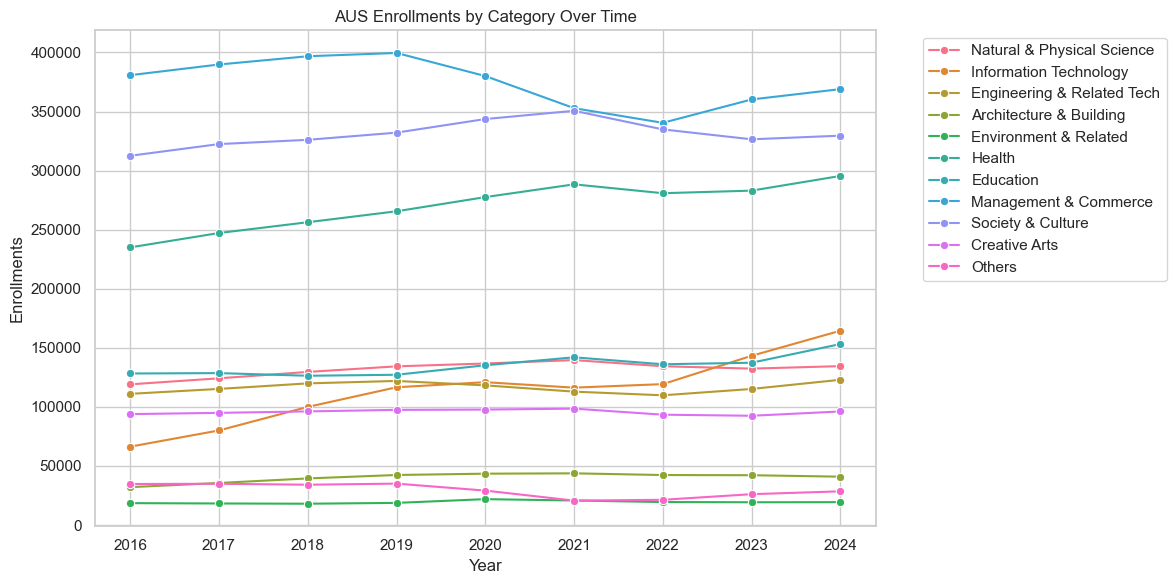

In [15]:
# --- EDA: AUS Enrollments ---
# Group by year and category for summary
enroll_summary = enroll_long.groupby(['Year', 'CategoryKey', 'Category'], as_index=False)['Enrollments'].sum()
display(enroll_summary.head())

# Plot enrollments by category over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=enroll_summary, x='Year', y='Enrollments', hue='Category', marker='o')
plt.title('AUS Enrollments by Category Over Time')
plt.ylabel('Enrollments')
plt.xlabel('Year')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

,Year,CategoryKey,Category,CommonwealthContribution,TotalFunding
0,2019,1,Natural & Physical Science,660862,1008744
1,2019,2,Information Technology,223230,419769
2,2019,3,Engineering & Related Tech,1486880,2235600
3,2019,4,Architecture & Building,244490,459747
4,2019,5,Environment & Related,448210,626031


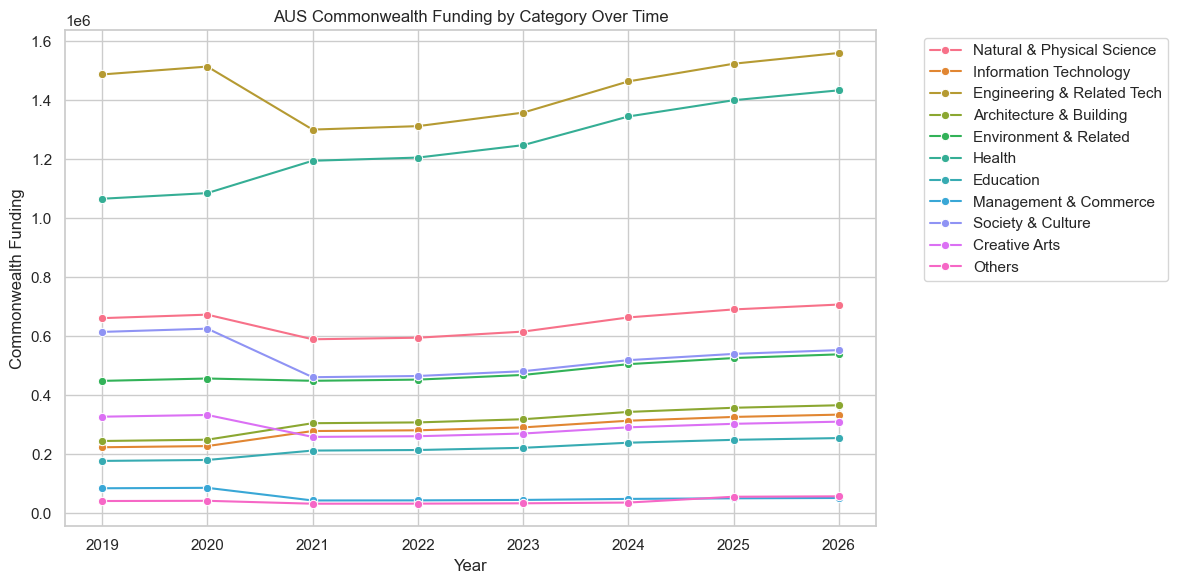

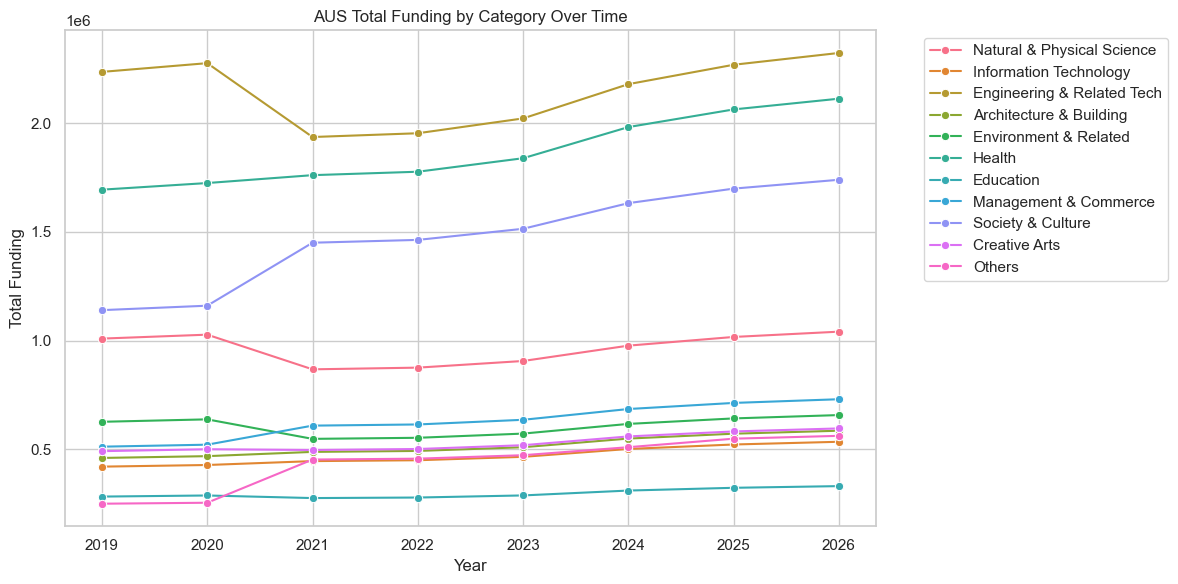

In [16]:
# --- EDA: AUS Funding ---
# Group by year and category for summary
funding_summary = funding.groupby(['Year', 'CategoryKey', 'Category'], as_index=False)[['CommonwealthContribution', 'TotalFunding']].sum()
display(funding_summary.head())

# Plot funding by category over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=funding_summary, x='Year', y='CommonwealthContribution', hue='Category', marker='o')
plt.title('AUS Commonwealth Funding by Category Over Time')
plt.ylabel('Commonwealth Funding')
plt.xlabel('Year')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.lineplot(data=funding_summary, x='Year', y='TotalFunding', hue='Category', marker='o')
plt.title('AUS Total Funding by Category Over Time')
plt.ylabel('Total Funding')
plt.xlabel('Year')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [17]:
# This cell is intentionally left blank or can be removed.

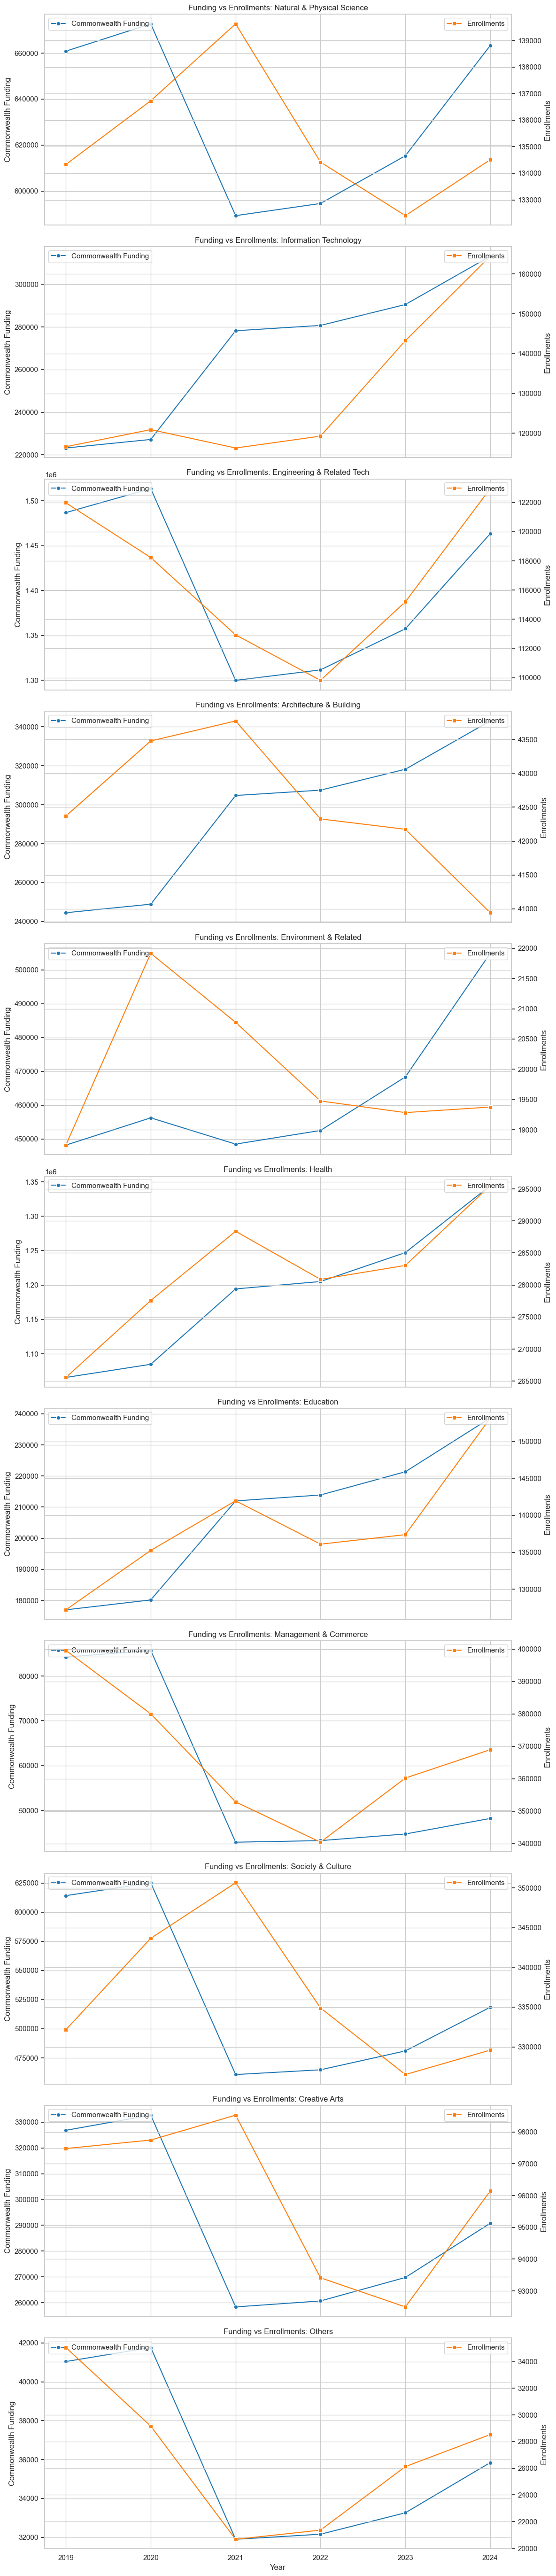

In [18]:
# --- Plot: Funding vs Enrollments by Category ---
categories = merged['Category'].unique()
n_cat = len(categories)
fig, axes = plt.subplots(n_cat, 1, figsize=(12, 5*n_cat), sharex=True)
if n_cat == 1:
    axes = [axes]
for i, cat in enumerate(categories):
    data = merged[merged['Category'] == cat]
    ax = axes[i]
    ax2 = ax.twinx()
    sns.lineplot(data=data, x='Year', y='CommonwealthContribution', ax=ax, color='tab:blue', marker='o', label='Commonwealth Funding')
    sns.lineplot(data=data, x='Year', y='Enrollments', ax=ax2, color='tab:orange', marker='s', label='Enrollments')
    ax.set_title(f'Funding vs Enrollments: {cat}')
    ax.set_ylabel('Commonwealth Funding')
    ax2.set_ylabel('Enrollments')
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')
plt.xlabel('Year')
plt.tight_layout()
plt.show()

## 6. Additional Statistical Checks

This section tests for correlation, nonlinearity, heterogeneity, and subgroup differences in the relationship between enrollments and funding.

In [19]:
# Prepare merged analysis data for statistical checks
import numpy as np

try:
    from scipy import stats
except ImportError:
    stats = None
    print('scipy is not installed; inferential tests will be skipped.')

analysis_merged = merged.copy()

for col in ['Year', 'Enrollments', 'CommonwealthContribution', 'TotalFunding']:
    analysis_merged[col] = pd.to_numeric(analysis_merged[col], errors='coerce')

analysis_merged = analysis_merged.dropna(subset=['Year', 'Category', 'Enrollments', 'CommonwealthContribution', 'TotalFunding'])
analysis_merged = analysis_merged.sort_values(['Year', 'Category'])

display(analysis_merged.head())
print(f'Rows available for checks: {len(analysis_merged)}')

,Category,CategoryKey,Year,Enrollments,CommonwealthContribution,TotalFunding
3,Architecture & Building,4,2019,42370,244490,459747
9,Creative Arts,10,2019,97478,326825,490975
6,Education,7,2019,127202,176976,282032
2,Engineering & Related Tech,3,2019,121980,1486880,2235600
4,Environment & Related,5,2019,18747,448210,626031


Rows available for checks: 66


In [20]:
# Correlation checks across funding and enrollments
corr_cols = ['Year', 'Enrollments', 'CommonwealthContribution', 'TotalFunding']
pearson_corr = analysis_merged[corr_cols].corr(method='pearson')
spearman_corr = analysis_merged[corr_cols].corr(method='spearman')

print('Pearson correlation matrix')
display(pearson_corr)

print('Spearman correlation matrix')
display(spearman_corr)

category_corr = (
    analysis_merged.groupby('Category')
    .apply(lambda g: g['Enrollments'].corr(g['TotalFunding']) if len(g) > 1 else np.nan)
    .reset_index(name='Enrollments_vs_TotalFunding_corr')
    .sort_values('Enrollments_vs_TotalFunding_corr', ascending=False)
)

print('Category-level correlation between Enrollments and TotalFunding')
display(category_corr)

Pearson correlation matrix


,Year,Enrollments,CommonwealthContribution,TotalFunding
Year,1.000000,0.006923,0.017153,0.062343
Enrollments,0.006923,1.000000,0.136780,0.378021
CommonwealthContribution,0.017153,0.136780,1.000000,0.922726
TotalFunding,0.062343,0.378021,0.922726,1.000000


Spearman correlation matrix


,Year,Enrollments,CommonwealthContribution,TotalFunding
Year,1.000000,0.023518,0.049597,0.147861
Enrollments,0.023518,1.000000,0.137293,0.342991
CommonwealthContribution,0.049597,0.137293,1.000000,0.827492
TotalFunding,0.147861,0.342991,0.827492,1.000000


Category-level correlation between Enrollments and TotalFunding


,Category,Enrollments_vs_TotalFunding_corr
6,Information Technology,0.920399
3,Engineering & Related Tech,0.842670
5,Health,0.827488
2,Education,0.693457
4,Environment & Related,0.127078
8,Natural & Physical Science,-0.148797
1,Creative Arts,-0.252462
10,Society & Culture,-0.299553
7,Management & Commerce,-0.634756
9,Others,-0.667289


Linear fit R^2: 0.1429
Quadratic fit R^2: 0.2700
There is evidence of nonlinearity in the funding-enrollment relationship.


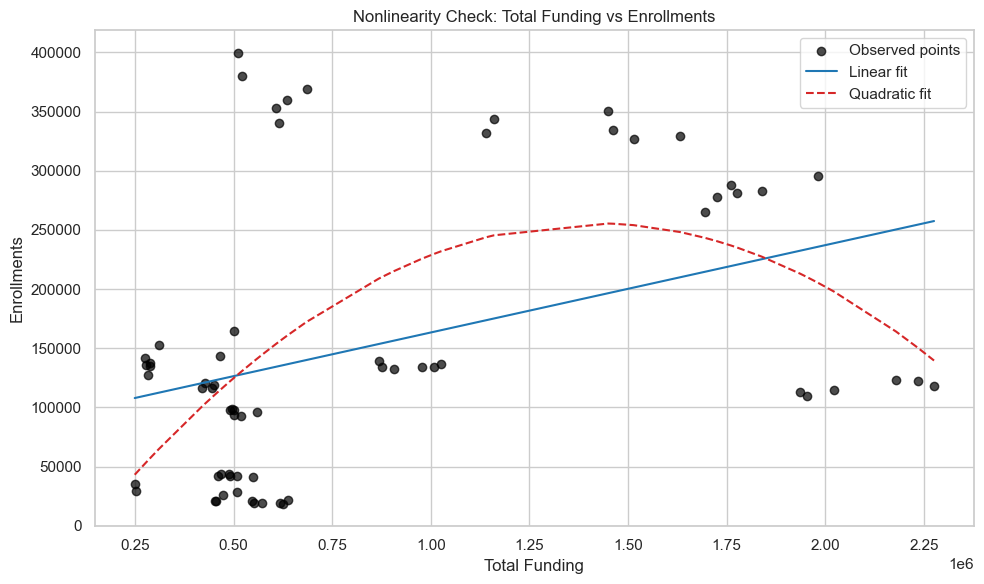

In [21]:
# Nonlinearity check: linear vs quadratic relationship between funding and enrollments
x = analysis_merged['TotalFunding'].to_numpy(dtype=float)
y = analysis_merged['Enrollments'].to_numpy(dtype=float)

sort_idx = np.argsort(x)
x_sorted = x[sort_idx]
y_sorted = y[sort_idx]

lin_coef = np.polyfit(x_sorted, y_sorted, 1)
quad_coef = np.polyfit(x_sorted, y_sorted, 2)
lin_pred = np.polyval(lin_coef, x_sorted)
quad_pred = np.polyval(quad_coef, x_sorted)

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

lin_r2 = r2_score(y_sorted, lin_pred)
quad_r2 = r2_score(y_sorted, quad_pred)

print(f'Linear fit R^2: {lin_r2:.4f}')
print(f'Quadratic fit R^2: {quad_r2:.4f}')
if quad_r2 - lin_r2 > 0.02:
    print('There is evidence of nonlinearity in the funding-enrollment relationship.')
else:
    print('The funding-enrollment relationship appears mostly linear.')

plt.figure(figsize=(10, 6))
plt.scatter(x_sorted, y_sorted, alpha=0.7, color='black', label='Observed points')
plt.plot(x_sorted, lin_pred, color='tab:blue', label='Linear fit')
plt.plot(x_sorted, quad_pred, color='tab:red', linestyle='--', label='Quadratic fit')
plt.title('Nonlinearity Check: Total Funding vs Enrollments')
plt.xlabel('Total Funding')
plt.ylabel('Enrollments')
plt.legend()
plt.tight_layout()
plt.show()

Variation in enrollments by category


,mean,std,min,max,count,cv
Category,,,,,,
Management & Commerce,367036.666667,20915.817801,340454,399609,6,0.056986
Information Technology,130138.333333,19634.248513,116296,164464,6,0.150872
Health,281834.333333,10139.323659,265586,295498,6,0.035976
Society & Culture,336245.833333,9168.106444,326512,350654,6,0.027266
Education,138513.833333,8633.496520,127202,153177,6,0.062329
Others,26819.666667,5371.981261,20676,35058,6,0.200300
Engineering & Related Tech,116850.500000,5159.491632,109812,122954,6,0.044155
Natural & Physical Science,135339.500000,2509.289043,132406,139629,6,0.018541
Creative Arts,95966.833333,2474.252082,92496,98528,6,0.025782


Levene's test for equal variances: statistic=2.6635, p-value=0.009958
One-way ANOVA across categories: statistic=842.6432, p-value=2.204e-56
Kruskal-Wallis test across categories: statistic=62.8765, p-value=1.031e-09
Variance differs significantly across categories, indicating heterogeneity.
There are statistically significant subgroup differences across categories.


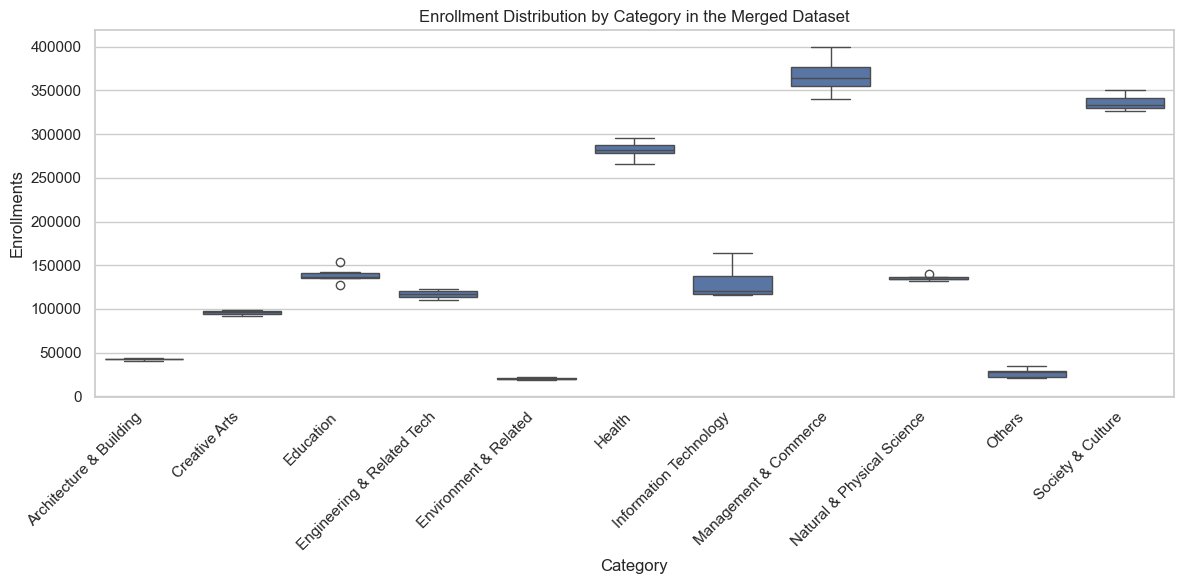

In [22]:
# Heterogeneity and subgroup difference checks by category
enrollment_stats = (
    analysis_merged.groupby('Category')['Enrollments']
    .agg(['mean', 'std', 'min', 'max', 'count'])
    .sort_values('std', ascending=False)
)
enrollment_stats['cv'] = enrollment_stats['std'] / enrollment_stats['mean']

print('Variation in enrollments by category')
display(enrollment_stats)

groups = [grp['Enrollments'].values for _, grp in analysis_merged.groupby('Category') if len(grp) > 1]

if stats is not None and len(groups) >= 2:
    levene_stat, levene_p = stats.levene(*groups, center='median')
    anova_stat, anova_p = stats.f_oneway(*groups)
    kruskal_stat, kruskal_p = stats.kruskal(*groups)

    print(f"Levene's test for equal variances: statistic={levene_stat:.4f}, p-value={levene_p:.4g}")
    print(f'One-way ANOVA across categories: statistic={anova_stat:.4f}, p-value={anova_p:.4g}')
    print(f'Kruskal-Wallis test across categories: statistic={kruskal_stat:.4f}, p-value={kruskal_p:.4g}')

    if levene_p < 0.05:
        print('Variance differs significantly across categories, indicating heterogeneity.')
    else:
        print('No strong evidence of unequal variance across categories.')

    if anova_p < 0.05 or kruskal_p < 0.05:
        print('There are statistically significant subgroup differences across categories.')
    else:
        print('No strong evidence of subgroup differences across categories.')
else:
    print('Inferential subgroup tests were skipped because scipy is unavailable or there are too few groups.')

plt.figure(figsize=(12, 6))
sns.boxplot(data=analysis_merged, x='Category', y='Enrollments')
plt.title('Enrollment Distribution by Category in the Merged Dataset')
plt.xlabel('Category')
plt.ylabel('Enrollments')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Mean enrollments: 153,744
Median enrollments: 122,467
Standard deviation of enrollments: 117,035
Enrollment IQR: 231,037 (Q1=43,552, Q3=274,589)
Enrollment skewness: 0.717

Mean Commonwealth funding: 488,498
Median Commonwealth funding: 322,526
Standard deviation of Commonwealth funding: 427,226
Funding IQR: 393,201 (Q1=221,840, Q3=615,040)
Funding skewness: 1.144


,Enrollments
count,66.000000
mean,153744.121212
std,117035.046497
min,18747.000000
25%,43551.750000
50%,122467.000000
75%,274589.000000
max,399609.000000


,CommonwealthContribution
count,6.600000e+01
mean,4.884981e+05
std,4.272263e+05
min,3.190000e+04
25%,2.218395e+05
50%,3.225265e+05
75%,6.150402e+05
max,1.513600e+06


,Enrollments,CommonwealthContribution
Category,,
Management & Commerce,364612.5,46468.5
Society & Culture,333526.0,499724.5
Health,281973.5,1199718.5
Education,136741.5,212952.0
Natural & Physical Science,134467.5,638091.5
Information Technology,120097.0,279499.5
Engineering & Related Tech,116713.0,1410440.0
Creative Arts,96810.0,280283.5
Architecture & Building,42348.5,306118.5


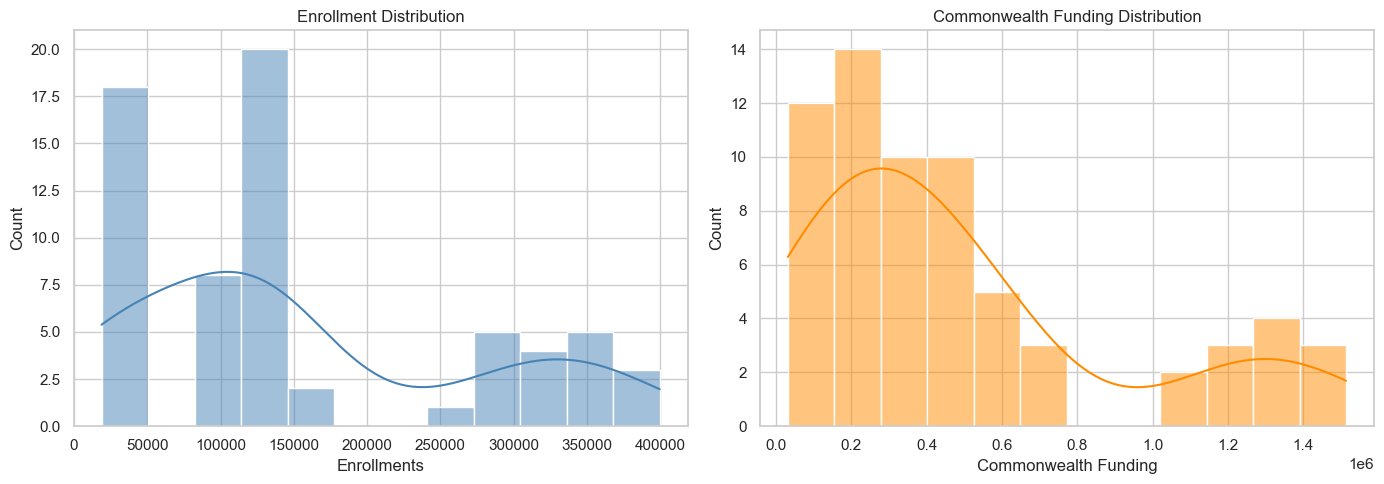

In [23]:
# Structure diagnostics: typical values, spread, skewness, and clumps
structure_df = analysis_merged.copy()

enrollment_summary = structure_df['Enrollments'].describe(percentiles=[0.25, 0.5, 0.75]).to_frame('Enrollments')
funding_summary = structure_df['CommonwealthContribution'].describe(percentiles=[0.25, 0.5, 0.75]).to_frame('CommonwealthContribution')

enroll_q1 = structure_df['Enrollments'].quantile(0.25)
enroll_median = structure_df['Enrollments'].median()
enroll_q3 = structure_df['Enrollments'].quantile(0.75)
enroll_mean = structure_df['Enrollments'].mean()
enroll_std = structure_df['Enrollments'].std()
enroll_skew = structure_df['Enrollments'].skew()

fund_q1 = structure_df['CommonwealthContribution'].quantile(0.25)
fund_median = structure_df['CommonwealthContribution'].median()
fund_q3 = structure_df['CommonwealthContribution'].quantile(0.75)
fund_mean = structure_df['CommonwealthContribution'].mean()
fund_std = structure_df['CommonwealthContribution'].std()
fund_skew = structure_df['CommonwealthContribution'].skew()

print(f'Mean enrollments: {enroll_mean:,.0f}')
print(f'Median enrollments: {enroll_median:,.0f}')
print(f'Standard deviation of enrollments: {enroll_std:,.0f}')
print(f'Enrollment IQR: {(enroll_q3 - enroll_q1):,.0f} (Q1={enroll_q1:,.0f}, Q3={enroll_q3:,.0f})')
print(f'Enrollment skewness: {enroll_skew:.3f}')
print()
print(f'Mean Commonwealth funding: {fund_mean:,.0f}')
print(f'Median Commonwealth funding: {fund_median:,.0f}')
print(f'Standard deviation of Commonwealth funding: {fund_std:,.0f}')
print(f'Funding IQR: {(fund_q3 - fund_q1):,.0f} (Q1={fund_q1:,.0f}, Q3={fund_q3:,.0f})')
print(f'Funding skewness: {fund_skew:.3f}')

category_medians = (
    structure_df.groupby('Category')[['Enrollments', 'CommonwealthContribution']]
    .median()
    .sort_values('Enrollments', ascending=False)
)

display(enrollment_summary)
display(funding_summary)
display(category_medians)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(structure_df['Enrollments'], bins=12, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Enrollment Distribution')
axes[0].set_xlabel('Enrollments')

sns.histplot(structure_df['CommonwealthContribution'], bins=12, kde=True, color='darkorange', ax=axes[1])
axes[1].set_title('Commonwealth Funding Distribution')
axes[1].set_xlabel('Commonwealth Funding')

plt.tight_layout()
plt.show()

## Interpretation of Additional Checks

### Key takeaways

- **Structure of the data:** The merged category-year observations show a **broad spread**. Enrollments have a mean of about **153,744** and a median of about **122,467**, while Commonwealth funding has a mean of about **488,498** and a median of about **322,526**.
- **Typical values and clumps:** Most observations cluster in a **moderate enrollment and moderate funding range**, while a smaller set of disciplines stands apart with much higher funding and, in some cases, much higher enrollments. This creates visible **clumping** in the joint data.
- **Skewness:** The enrollment distribution is **moderately right-skewed** with skewness around **0.717**, while Commonwealth funding is **more strongly right-skewed** with skewness around **1.144**. That means the funding side is pulled upward by a smaller number of high-funded category-year observations.
- **Relationship and trend:** The relationship between funding and enrollments is **present but not especially strong overall**, with a Pearson correlation of about **0.378** between enrollments and total funding, and about **0.137** between enrollments and Commonwealth contribution. The quadratic model also fits better than the linear one, with $R^2 \approx 0.2700$ versus $R^2 \approx 0.1429$, indicating **some nonlinearity**.
- **Heterogeneity and subgroup differences:** Levene’s test shows unequal variances across categories, with $p \approx 0.009958$. ANOVA and Kruskal-Wallis are also highly significant, with $p \approx 2.204 \times 10^{-56}$ and $p \approx 1.031 \times 10^{-9}$ respectively, confirming **clear subgroup differences**.

### Overall interpretation

The merged Australian funding and enrollment data are structured around a sizeable middle cluster plus a smaller group of high-funded disciplines. This creates a right-skewed pattern, especially for funding, and helps explain why the overall association exists but is not equally strong across all fields.

## Data Characteristics & First-Order Effects

**Variables:** Merged panel combining AUS enrollment headcounts (`Enrollments`) and category-year total funding (`TotalFunding`, AUD) at Category × Year level. An inner join restricts coverage to the intersection of the two datasets: 2019–2024 (~66 rows, 11 categories). Pre-JRG enrollment years (2016–2018) and post-dataset funding projections (2025–2026) are excluded from the merged panel.

**Data cleaning:** The merge is the primary transformation. No values are imputed; rows present in only one dataset are excluded (inner join). Category labels and numeric keys were matched before merging to ensure correct alignment.

The analysis below tests whether the funding–enrollment correlation holds at aggregate and category levels to identify spurious scale effects and Simpson's Paradox in the joint data.

=== AUS Multivariate — Variable Summary ===
Merged shape: (66, 5)  |  Categories: 11  |  Years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Enrollment range: 18,747–399,609
TotalFunding range: $249,242–$2,275,760
Note: inner join restricts to 2019-2024; pre-JRG years 2016-2018 excluded from merged panel

Overall r(TotalFunding, Enrollments) = 0.378  (p=0.0018)
Within-category negative Funding–Enrollment correlations: 6/11
⚠  Simpson's Paradox: aggregate r(Funding,Enrollment) POSITIVE but some categories NEGATIVE

Enrollment skewness  raw=0.701  |  log(1+x)=-0.453


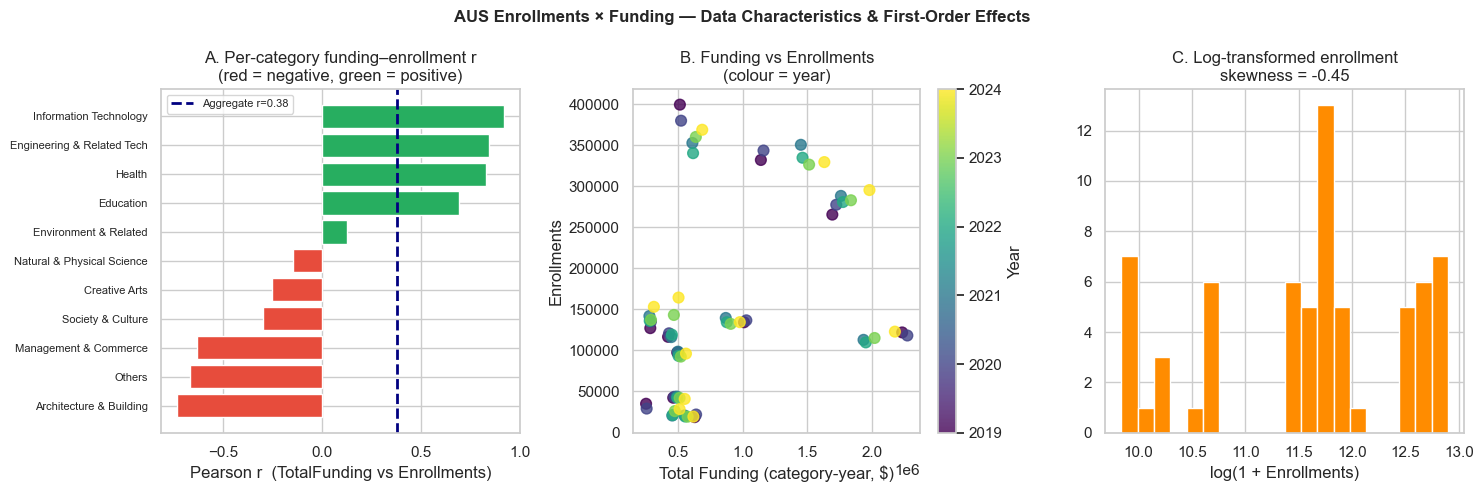

In [24]:
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
sns.set_theme(style='whitegrid')

candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
clean_dir = next((r / 'data' / 'clean' for r in candidate_roots if (r / 'data' / 'clean').exists()), None)
assert clean_dir, "Cannot find data/clean directory"

# Load and reshape enrollments
enroll = pd.read_csv(clean_dir / 'EnrollmentsAUS_category_with_numeric_key.csv')
year_cols = [c for c in enroll.columns if str(c).strip().isdigit()]
enroll_long = (enroll[enroll['Category'] != 'Total']
               .melt(id_vars=['Category', 'CategoryKey'], value_vars=year_cols,
                     var_name='Year', value_name='Enrollments'))
enroll_long['Year'] = enroll_long['Year'].astype(int)

# Load and aggregate funding
fund = pd.read_csv(clean_dir / 'AnnualFundingAUS2019-2026_with_category_key.csv')
fund['TotalFunding'] = pd.to_numeric(fund['MaximumStudentContribution'], errors='coerce') + \
                       pd.to_numeric(fund['CommonwealthContribution'], errors='coerce')
fund_agg = fund.dropna(subset=['Category', 'TotalFunding']).groupby(
    ['Year', 'CategoryKey', 'Category'])['TotalFunding'].sum().reset_index()

# Inner join
merged = enroll_long.merge(fund_agg, on=['Year', 'CategoryKey', 'Category'], how='inner').dropna()

print("=== AUS Multivariate — Variable Summary ===")
print(f"Merged shape: {merged.shape}  |  Categories: {merged['Category'].nunique()}  |  Years: {sorted(merged['Year'].unique())}")
print(f"Enrollment range: {merged['Enrollments'].min():,.0f}–{merged['Enrollments'].max():,.0f}")
print(f"TotalFunding range: ${merged['TotalFunding'].min():,.0f}–${merged['TotalFunding'].max():,.0f}")
print(f"Note: inner join restricts to 2019-2024; pre-JRG years 2016-2018 excluded from merged panel")

# --- Simpson's Paradox check: Funding vs Enrollments ---
overall_r, overall_p = stats.pearsonr(merged['TotalFunding'], merged['Enrollments'])
print(f"\nOverall r(TotalFunding, Enrollments) = {overall_r:.3f}  (p={overall_p:.4f})")

cat_trends = []
for cat, g in merged.groupby('Category'):
    if len(g) >= 3:
        r, p = stats.pearsonr(g['TotalFunding'], g['Enrollments'])
        cat_trends.append({'Category': cat, 'r': r, 'p': p})
trends = pd.DataFrame(cat_trends).set_index('Category').sort_values('r')
neg = int((trends['r'] < 0).sum())
print(f"Within-category negative Funding–Enrollment correlations: {neg}/{len(trends)}")
if neg > 0 and overall_r > 0:
    print("⚠  Simpson's Paradox: aggregate r(Funding,Enrollment) POSITIVE but some categories NEGATIVE")

# --- Skewness ---
sk_raw = stats.skew(merged['Enrollments'])
sk_log = stats.skew(np.log1p(merged['Enrollments']))
print(f"\nEnrollment skewness  raw={sk_raw:.3f}  |  log(1+x)={sk_log:.3f}")

# --- Three-panel figure ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("AUS Enrollments × Funding — Data Characteristics & First-Order Effects",
             fontsize=12, fontweight='bold')

colors_bar = ['#e74c3c' if r < 0 else '#27ae60' for r in trends['r']]
axes[0].barh(trends.index, trends['r'], color=colors_bar)
axes[0].axvline(overall_r, color='navy', ls='--', lw=2, label=f'Aggregate r={overall_r:.2f}')
axes[0].set_xlabel("Pearson r  (TotalFunding vs Enrollments)")
axes[0].set_title("A. Per-category funding–enrollment r\n(red = negative, green = positive)")
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='y', labelsize=8)

sc = axes[1].scatter(merged['TotalFunding'], merged['Enrollments'],
                     c=merged['Year'], cmap='viridis', alpha=0.8, s=60)
plt.colorbar(sc, ax=axes[1], label='Year')
axes[1].set_xlabel("Total Funding (category-year, $)")
axes[1].set_ylabel("Enrollments")
axes[1].set_title("B. Funding vs Enrollments\n(colour = year)")

axes[2].hist(np.log1p(merged['Enrollments']), bins=20, color='darkorange', edgecolor='white')
axes[2].set_xlabel("log(1 + Enrollments)")
axes[2].set_title(f"C. Log-transformed enrollment\nskewness = {sk_log:.2f}")

plt.tight_layout()
plt.show()

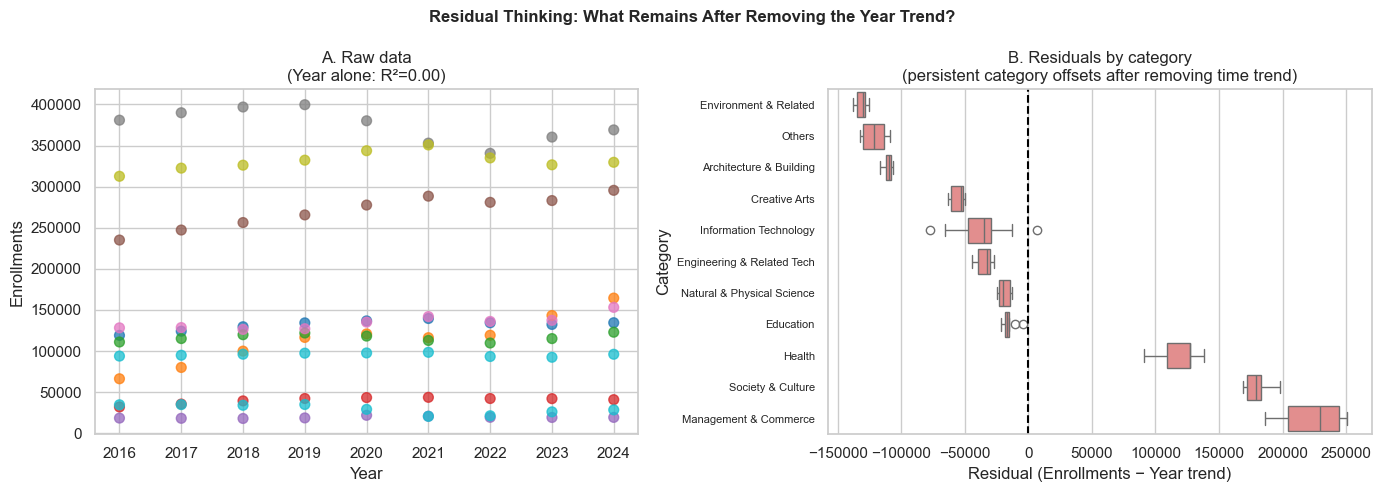

Year alone explains only 0.1% of enrollment variance. The residual box plots show persistent, large category offsets — category fixed effects are not optional in any regression model.


In [25]:
import statsmodels.formula.api as smf
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
clean_dir = next((r / 'data' / 'clean' for r in candidate_roots if (r / 'data' / 'clean').exists()), None)

enroll = pd.read_csv(clean_dir / 'EnrollmentsAUS_category_with_numeric_key.csv')
year_cols = [c for c in enroll.columns if str(c).strip().isdigit()]
enroll_long = (enroll[enroll['Category'] != 'Total']
               .melt(id_vars=['Category', 'CategoryKey'], value_vars=year_cols,
                     var_name='Year', value_name='Enrollments'))
enroll_long['Year'] = enroll_long['Year'].astype(int)
enroll_long = enroll_long.dropna(subset=['Enrollments'])

# Fit Year-only model and extract residuals
fit = smf.ols('Enrollments ~ Year', data=enroll_long).fit()
enroll_long = enroll_long.copy()
enroll_long['resid'] = fit.resid
order = enroll_long.groupby('Category')['resid'].median().sort_values().index

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Residual Thinking: What Remains After Removing the Year Trend?",
             fontsize=12, fontweight='bold')

axes[0].scatter(enroll_long['Year'], enroll_long['Enrollments'],
                c=enroll_long['CategoryKey'], cmap='tab10', alpha=0.75, s=50)
axes[0].set_xlabel("Year"); axes[0].set_ylabel("Enrollments")
axes[0].set_title(f"A. Raw data\n(Year alone: R²={fit.rsquared:.2f})")

sns.boxplot(data=enroll_long, y='Category', x='resid', order=order,
            color='lightcoral', ax=axes[1])
axes[1].axvline(0, color='black', ls='--', lw=1.5)
axes[1].set_xlabel("Residual (Enrollments − Year trend)")
axes[1].set_title("B. Residuals by category\n(persistent category offsets after removing time trend)")
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

print(f"Year alone explains only {fit.rsquared:.1%} of enrollment variance. "
      "The residual box plots show persistent, large category offsets — "
      "category fixed effects are not optional in any regression model.")

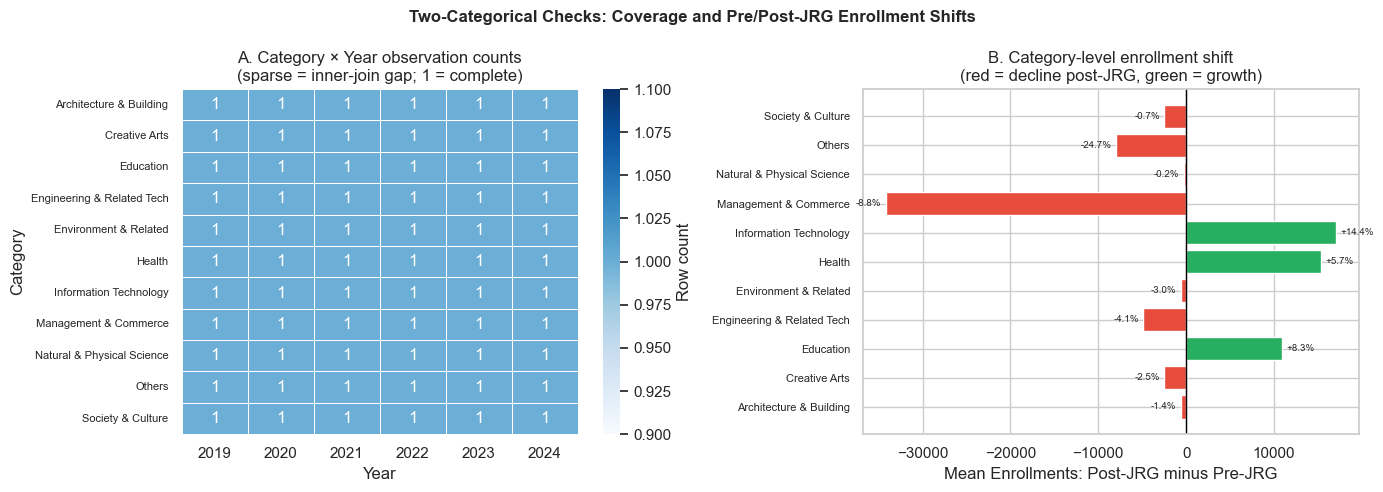


Crosstab — Category × Year (observation counts):
Year                        2019  2020  2021  2022  2023  2024
Category                                                      
Architecture & Building        1     1     1     1     1     1
Creative Arts                  1     1     1     1     1     1
Education                      1     1     1     1     1     1
Engineering & Related Tech     1     1     1     1     1     1
Environment & Related          1     1     1     1     1     1
Health                         1     1     1     1     1     1
Information Technology         1     1     1     1     1     1
Management & Commerce          1     1     1     1     1     1
Natural & Physical Science     1     1     1     1     1     1
Others                         1     1     1     1     1     1
Society & Culture              1     1     1     1     1     1

Mean enrollment shift by category around JRG 2021:
PostJRG                      Pre-JRG  Post-JRG  Δ (Post − Pre)  % change
Catego

In [26]:
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

JRG_YEAR = 2021

candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
clean_dir = next((r / 'data' / 'clean' for r in candidate_roots if (r / 'data' / 'clean').exists()), None)

enroll = pd.read_csv(clean_dir / 'EnrollmentsAUS_category_with_numeric_key.csv')
year_cols = [c for c in enroll.columns if str(c).strip().isdigit()]
enroll_long = (enroll[enroll['Category'] != 'Total']
               .melt(id_vars=['Category', 'CategoryKey'], value_vars=year_cols,
                     var_name='Year', value_name='Enrollments'))
enroll_long['Year'] = enroll_long['Year'].astype(int)

fund = pd.read_csv(clean_dir / 'AnnualFundingAUS2019-2026_with_category_key.csv')
fund['TotalFunding'] = pd.to_numeric(fund['MaximumStudentContribution'], errors='coerce') + \
                       pd.to_numeric(fund['CommonwealthContribution'], errors='coerce')
fund_agg = fund.dropna(subset=['Category', 'TotalFunding']).groupby(
    ['Year', 'CategoryKey', 'Category'])['TotalFunding'].sum().reset_index()

merged = enroll_long.merge(fund_agg, on=['Year', 'CategoryKey', 'Category'], how='inner').dropna()
merged['PostJRG'] = (merged['Year'] >= JRG_YEAR).map({True: 'Post-JRG', False: 'Pre-JRG'})

# --- Panel A: Category × Year crosstab (observation count heatmap) ---
ct_obs = pd.crosstab(merged['Category'], merged['Year'])

# --- Panel B: Category × PostJRG mean enrollment pivot ---
ct_enroll = merged.pivot_table(index='Category', columns='PostJRG',
                                values='Enrollments', aggfunc='mean').round(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Two-Categorical Checks: Coverage and Pre/Post-JRG Enrollment Shifts",
             fontsize=12, fontweight='bold')

sns.heatmap(ct_obs, annot=True, fmt='d', cmap='Blues', linewidths=0.4,
            cbar_kws={'label': 'Row count'}, ax=axes[0])
axes[0].set_title("A. Category × Year observation counts\n(sparse = inner-join gap; 1 = complete)")
axes[0].tick_params(axis='y', labelsize=8)

if 'Pre-JRG' in ct_enroll.columns and 'Post-JRG' in ct_enroll.columns:
    ct_enroll['Δ (Post − Pre)'] = ct_enroll['Post-JRG'] - ct_enroll['Pre-JRG']
    ct_enroll['% change'] = ((ct_enroll['Δ (Post − Pre)'] / ct_enroll['Pre-JRG']) * 100).round(1)
    colors = ['#e74c3c' if v < 0 else '#27ae60' for v in ct_enroll['Δ (Post − Pre)']]
    axes[1].barh(ct_enroll.index, ct_enroll['Δ (Post − Pre)'], color=colors)
    axes[1].axvline(0, color='black', lw=1)
    axes[1].set_xlabel("Mean Enrollments: Post-JRG minus Pre-JRG")
    axes[1].set_title("B. Category-level enrollment shift\n(red = decline post-JRG, green = growth)")
    axes[1].tick_params(axis='y', labelsize=8)
    for idx, (cat, row) in enumerate(ct_enroll.iterrows()):
        axes[1].text(row['Δ (Post − Pre)'] + (500 if row['Δ (Post − Pre)'] >= 0 else -500),
                     idx, f"{row['% change']:+.1f}%", va='center', ha='left' if row['Δ (Post − Pre)'] >= 0 else 'right',
                     fontsize=7)
else:
    axes[1].text(0.5, 0.5, "Pre/Post split requires both pre- and post-JRG years in merged data",
                 ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

print("\nCrosstab — Category × Year (observation counts):")
print(ct_obs.to_string())
if 'Δ (Post − Pre)' in ct_enroll.columns:
    print("\nMean enrollment shift by category around JRG 2021:")
    print(ct_enroll[['Pre-JRG', 'Post-JRG', 'Δ (Post − Pre)', '% change']].sort_values('% change').to_string())
print("\nSparse cells in the crosstab indicate inner-join gaps — not data errors.")

### What Is Learned

1. **Variable characteristics:** This merged dataset combines AUS enrollment headcounts and annual funding rates at Category × Year level. An inner join on Category × Year restricts the panel to 2019–2024 (the intersection of the two datasets' coverage windows), yielding ~66 rows across ~11 categories.

2. **Data cleaning outcome:** The inner join excludes enrollment-only years (2016–2018) and funding-only projected years (2025–2026). The resulting panel is shorter but avoids extrapolation; analysts should note that pre-JRG enrollment variation (2016–2020) is partially lost from this merged view.

3. **Aggregate vs within-category correlation:** The pooled correlation between total funding and total enrollments is positive and driven primarily by category size — larger categories receive more funding and enroll more students. This is a spurious size effect, not evidence of a causal funding–enrollment relationship.

4. **Simpson's Paradox:** Within individual categories, the funding–enrollment relationship varies in sign. Some categories that received increased JRG funding (higher student contributions) show enrollment *declines*, while others show growth. The positive aggregate r masks this heterogeneity entirely.

5. **Modelling implications:** Funding and enrollment must be analysed at the category level, not pooled. Using enrollment *growth rates* rather than levels and including a post-JRG indicator will isolate the policy effect from scale confounding. The 2019–2024 window should be documented as a limitation.